# Expressibility and entangling capability of parameterized quantum circuits for hybrid quantum-classical algorithms

In this document, we are replicating the work by S.Sim,P.D.Johnson and A.Aspuru-Guzik *Adv.Quantum.Technol.* **2** 1900070 (2019): https://arxiv.org/abs/1905.10876

Consider a parameterized quantum circuit $U(\mathbf{x})$, and define the quantity
$$f(\mathbf{x},\mathbf{y}) = |\langle 0 | U^{\dagger}(\mathbf{y})U(\mathbf{x})|0\rangle|^{2}$$
This quantity is the fidelity of the two states
$$\begin{align*}
|\psi_{\mathbf{x}}\rangle = U(\mathbf{x})|0\rangle~~&\text{and}~~|\psi_{\mathbf{y}}\rangle = U(\mathbf{y})|0\rangle:\\
|\langle \psi_{\mathbf{y}}|\psi_{\mathbf{x}}\rangle|^{2} &= |\langle 0 |U^{\dagger}(\mathbf{y})U(\mathbf{x})|0\rangle|^{2}.
\end{align*}$$

Suppose we generate a bunch of random realizations of $\mathbf{x},\mathbf{y}$. This gives us a set of random realizations of $f$; let's call that set $F = \{f_{1}, f_{2}, \cdots \}$.

To calculate the expressibility, we need to do 2 things:
* Generate a _histogram_ of the elements of $F$. The output of this histogram is a set of bins $B = \{(l_1, u_1), (l_2, u_2), \cdots \}$ where $l_{j}$ ($u_j$) denotes the lower (upper) limit of bin $j$. It also produces an empirical probability distribution function $\mathrm{Pr}_{\text{emp}}(j)$, which is simply the probability that a given value of $f$ falls in a bin $j$.
* Given the bins of the histogram, we need to compute the probability that a given fidelity value would fall into bin $j$ if the circuit generating that fidelity is drawn from a Haar-random distribution. If the circuit acts on $n$ qubits, the probability of a given fidelity value $f$ is:
$$ \mathrm{Pr}_{\text{Haar}}(f) = (N -1)*(1-f)^{N-2}~~N=2^{n}.$$
To calculate the probability over a bin of the histogram, we do an integral:
$$\mathrm{Pr}_{\text{Haar}}(j) = \int_{l_{j}}^{u_{j}}  \mathrm{Pr}_{\text{Haar}}(f) ~df =  (1-l_{j})^{N-1}  - (1-u_{j})^{N-1}$$
The expressibility is then estimated as the KL divergence between the empirically-observed probability distribution (i.e., the histogram) and the probability distribution that would result under a Haar-random unitary.
$$\text{Expr} = \mathrm{KL}(\mathrm{Pr}_{\text{emp}}|| \mathrm{Pr}_{\text{Haar}}) = \sum_{j} \mathrm{Pr}_{\text{emp}}(j)\log\left(\frac{\mathrm{Pr}_{\text{emp}}(j)}{\mathrm{Pr}_{\text{Haar}}(j)}\right)$$

## Imports

In [1]:
import os

import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit,Parameter, QuantumRegister, ClassicalRegister, Gate, Measure
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip
from toqito import state_props

import numpy as np
from scipy.linalg import expm as expMatrix
import math

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd

from qiskit_qc import *

from math import pi, sqrt

from scipy.special import rel_entr
from scipy.stats import entropy
from scipy.special import kl_div, rel_entr
from random import seed
from random import random,choice
import random
import cmath

## Bins

In [2]:
def P_harr(l,u,N):
    return (1-l)**(N-1)-(1-u)**(N-1)

def bins(N_qubits):
    #Possible Bin
    bins_list=[]
    for i in range(76):
        bins_list.append((i)/75)
    #Center of the Bean
    bins_x=[]    
    for i in range(75):
        bins_x.append(bins_list[1]+bins_list[i])
    
    #Harr histogram
    P_harr_hist=[]
    for i in range(75):
        P_harr_hist.append(P_harr(bins_list[i],bins_list[i+1],2**(N_qubits)))    
    #Imaginary    
    #j=(-1)**(1/2)
    return P_harr_hist, bins_x, bins_list

## Idle Circuit

In [ ]:
qasm_simulator = Aer.get_backend("qasm_simulator")

n_shots=10000
simulation_samples=4000
fidelity=[]    
for x in range(simulation_samples):
    th=2*pi*random()
    qr = QuantumRegister(1)
    cr = ClassicalRegister(1)
    qc = QuantumCircuit(qr, cr)
    qc.id(qr[0])
    qc.id(qr[0])
    qc.measure(qr[0],cr[0])
    
    if x==0:
        qc.draw('mpl')

    job = qasm_simulator.run(qc, n_shots=n_shots)
    result = job.result()
    count = result.get_counts()

    if '0' in count:
        ratio=count['0']/n_shots
    else:
        ratio=0
    fidelity.append(ratio)

P_harr_hist, bins_x, bins_list=bins(N_qubits=1)

In [ ]:
qc.draw('mpl')

In [ ]:
weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, label='Idle', range=[0, 1])
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' % sum(kl_pq))

## Rascunho

In [ ]:
import numpy as np

def is_unitary(matrix, tol=1e-9):
    """
    Verifica se uma matriz é unitária.
    
    Uma matriz U é unitária se U†U = UU† = I, onde U† é a conjugada transposta de U.
    
    Parâmetros:
    matrix -- matriz a ser verificada (numpy array)
    tol -- tolerância para erros numéricos (float)
    
    Retorna:
    True se a matriz é unitária, False caso contrário
    """
    # Calcula a conjugada transposta da matriz
    conjugate_transpose = np.conj(matrix).T
    
    # Calcula U†U e UU†
    product1 = np.dot(conjugate_transpose, matrix)
    product2 = np.dot(matrix, conjugate_transpose)
    
    # Cria a matriz identidade do mesmo tamanho
    identity = np.eye(matrix.shape[0])
    
    # Verifica se ambos os produtos são iguais à identidade dentro da tolerância
    return (np.allclose(product1, identity, atol=tol) and 
            np.allclose(product2, identity, atol=tol))

tx = rng.random((1,NF))  # Parâmetros para tx
tw = rng2.random((1,NF))  # Parâmetros para tw
w=tw

# Simule o circuito para obter o vetor de estado
X_new=np.array(tx[0])
if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
    for k in range(2**(N_qubits-1) - N_features):
        w=np.append(w,0)
        X_new=np.append(X_new,0)
    sigmaE=np.diag(X_new)*w.T
else:
    sigmaE=np.diag(X_new)*w.T


# IQC

qc = QuantumCircuit(N_qubits)

qc.h(0)
qc.h(range(1,N_qubits))



#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

# qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
qc.unitary(U,qubits)

is_unitary(U)

## Criar circuito com objeto _Parameters_

In [3]:
def get_U_solo(X, W, N_features, N_qubits, N_qubits_tgt):
    w = np.array(W)

    X_new=np.array(X)

    if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
        for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
            w=np.append(w,0)
            X_new=np.append(X_new,0)
    
    #Montando os sigmas
    sigmaE=np.diag(X_new)*w.T
    
    if N_qubits_tgt==1:
        
        matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
        matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
        matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

        sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    else:
        sigma_q_params=np.full(2**N_qubits_tgt,1)
        sigmaQ=get_weighted_sigmaQ(sigma_q_params,iqcpq=True)

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))
    return U

def get_U_operator(params, N_features, N_qubits, N_qubits_tgt):
    data = params[:N_features]
    w = params[N_features:]
    w = [[x] for x in w]
    w = np.array(w)

    X_new=np.array(data)

    if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
        for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
            w=np.append(w,0)
            X_new=np.append(X_new,0)
    
    #Montando os sigmas
    sigmaE=np.diag(X_new)*w.T
    
    if N_qubits_tgt==1:
        
        matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
        matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
        matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

        sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    else:
        sigma_q_params=np.full(2**N_qubits_tgt,1)
        sigmaQ=get_weighted_sigmaQ(sigma_q_params,iqcpq=True)

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))
    return U

def get_U_operator_altered(params, N_features, N_qubits, N_qubits_tgt, iqcail=False,iqcndse=False, iqcangle=False):
    X = params[:N_features]
    vw = params[N_features:]
    #Montando os sigmas
    if iqcail==True:
        N_qubits_tgt=1
        X_new=np.array(X)
        w=np.array(vw)
        if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
            for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
                w=np.append(vw,0)
                X_new=np.append(X_new,0)
        
        sigmaE=np.diag(w)

    elif iqcndse==True:
        atx=np.array(X)
        atw=np.array(vw)
        if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
            for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
                atw=np.append(atw,0)
                atx=np.append(atx,0)
        X_new=np.matrix(atx)
        w=np.matrix(atw)
        # Ensure sigmaE is hermitian
        sigmaE = X_new.T @ w + (X_new.T @ w).T
    
    elif iqcangle==True:
        X_new=np.array(X)
        # Verifica se precisa ajustar sigmaE
        sigmaE = np.diag(w)
        # Calcula o operador unitário U
        dim_circuit = 2 ** (N_qubits - 1)
        dim_sigmaE = sigmaE.shape[0]
        sigmaE = np.kron(np.eye(dim_circuit // dim_sigmaE), sigmaE)
    
    else:
        w = np.array(vw)
        X_new=np.array(X)
        if np.log2(N_features)%2!=0 and np.log2(N_features)!=1:
            for k in range(2**(N_qubits-N_qubits_tgt) - N_features):
                w=np.append(w,0)
                X_new=np.append(X_new,0)
        sigmaE=np.diag(X_new)*w.T
    
    if N_qubits_tgt==1:
        sigma_q_params=np.full(2**N_qubits_tgt,1)
        sigmaQ=sigmaQ=get_weighted_sigmaQ(sigma_q_params,iqcpq=False)

    else:
        sigma_q_params=np.full(2**N_qubits_tgt,1)
        sigmaQ=get_weighted_sigmaQ(sigma_q_params,iqcpq=True)

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))
    return U

def conj_reversed_qc(qc: QuantumCircuit):
    rev_ops = reversed(qc.data)
    for gate, qargs, cargs in rev_ops:
        new_gate = gate
        if gate.params:
            new_params = [Parameter(f'conj_{param.name}') for param in gate.params]
            if hasattr(gate, 'N_features') and hasattr(gate, 'N_qubits_tgt'):
                # Caso especial para nosso gate personalizado
                new_gate = gate.__class__(name=gate.name,
                                        num_qubits=gate.num_qubits,
                                        params=new_params,
                                        N_features=gate.N_features,
                                        N_qubits_tgt=gate.N_qubits_tgt)
            else:
                # Para gates padrão do Qiskit
                new_gate = gate.__class__(name=gate.name,
                                        num_qubits=gate.num_qubits,
                                        params=new_params)
        
        qc.append(new_gate, qargs, cargs)
    return qc
        
def circuitm(model: str, N_features, N_qubits, N_qubits_tgt, params):
    if model == 'IQC':
        qc = QuantumCircuit(N_qubits)
        qc.h(range(N_qubits))
        
        class IQC_UGate(Gate):
            def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
                super().__init__(name, num_qubits, params)
                self.N_features = N_features
                self.N_qubits_tgt = N_qubits_tgt
                
            def _define(self):
                q = QuantumRegister(self.num_qubits, 'q')
                qc = QuantumCircuit(q)
                param_values = [0]*len(self.params)  # Valores temporários
                U = get_U_operator_altered(param_values, self.N_features, self.num_qubits, self.N_qubits_tgt)
                qc.unitary(U, range(self.num_qubits))
                self.definition = qc
            def validate_parameter(self, parameter):
                return parameter  # Aceita qualquer parâmetro
        
        unitary_gate = IQC_UGate(f'U_{model}', N_qubits, params, N_features, N_qubits_tgt)
        qc.append(unitary_gate, range(N_qubits))

    if model == 'IQCpQ':
        qc = QuantumCircuit(N_qubits)
        qc.h(range(N_qubits))
        
        class IQCpQ_UGate(Gate):
            def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
                super().__init__(name, num_qubits, params)
                self.N_features = N_features
                self.N_qubits_tgt = N_qubits_tgt
                
            def _define(self):
                q = QuantumRegister(self.num_qubits, 'q')
                qc = QuantumCircuit(q)
                param_values = [0]*len(self.params)  # Valores temporários
                U = get_U_operator_altered(param_values, self.N_features, self.num_qubits, self.N_qubits_tgt)
                qc.unitary(U, range(self.num_qubits))
                self.definition = qc
            def validate_parameter(self, parameter):
                return parameter  # Aceita qualquer parâmetro
        
        unitary_gate = IQCpQ_UGate(f'U_{model}', N_qubits, params, N_features, N_qubits_tgt)
        qc.append(unitary_gate, range(N_qubits))
    
    if model == 'IQCNDsE':
        qc = QuantumCircuit(N_qubits)
        qc.h(range(N_qubits))
        
        class IQCNDsE_UGate(Gate):
            def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
                super().__init__(name, num_qubits, params)
                self.N_features = N_features
                self.N_qubits_tgt = N_qubits_tgt
                
            def _define(self):
                q = QuantumRegister(self.num_qubits, 'q')
                qc = QuantumCircuit(q)
                param_values = [0]*len(self.params)  # Valores temporários
                U = get_U_operator_altered(param_values, self.N_features, self.num_qubits, self.N_qubits_tgt, iqcndse=True)
                qc.unitary(U, range(self.num_qubits))
                self.definition = qc
            def validate_parameter(self, parameter):
                return parameter  # Aceita qualquer parâmetro
        
        unitary_gate = IQCNDsE_UGate(f'U_{model}', N_qubits, params, N_features, N_qubits_tgt)
        qc.append(unitary_gate, range(N_qubits))

    if model == 'IQC_AIL':
        class ParamInitializeGate(Gate):
            def __init__(self, num_qubits, params, N_features):
                super().__init__("param_init", num_qubits, params)
                self.N_features = N_features
                
            def _define(self):
                q = QuantumRegister(self.num_qubits)
                qc = QuantumCircuit(q)
                
                # Convert parameters to normalized state vector
                params = np.array(self.params, dtype=complex)
                norm = np.linalg.norm(params)
                if norm > 0:
                    params = params/norm
                    
                qc.initialize(params, q[:])
                self.definition = qc
        
        def conj_reversed_qc_ail(qc: QuantumCircuit):
            rev_ops = reversed(qc.data)
            a=0
            for gate, qargs, cargs in rev_ops:
                new_gate = gate
                if a==0:
                    new_params = [Parameter(f'conj_{param.name}') for param in gate.params]
                if isinstance(gate, ParamInitializeGate):
                    # For our custom gate, just append as-is (parameters will be bound later)
                    new_gate = gate.__class__(num_qubits=gate.num_qubits,
                                        params=new_params[:gate.N_features],
                                        N_features=gate.N_features)
                elif hasattr(gate, 'N_features') and hasattr(gate, 'N_qubits_tgt'):
                    # Caso especial para nosso gate personalizado
                    new_gate = gate.__class__(name=gate.name,
                                            num_qubits=gate.num_qubits,
                                            params=new_params,
                                            N_features=gate.N_features,
                                            N_qubits_tgt=gate.N_qubits_tgt)
                    # Original handling for other gates
                    #new_gate = gate.inverse() if hasattr(gate, 'inverse') else gate
                a+=1
                qc.append(new_gate, qargs, cargs)
            return qc

        qc = QuantumCircuit(N_qubits)
        init_gate = ParamInitializeGate(N_qubits-1, params[:N_features], N_features=N_features)
        qc.append(init_gate, range(1,N_qubits))
        qc.h(0)
        
        class IQC_AIL_UGate(Gate):
            def __init__(self, name, num_qubits, params, N_features, N_qubits_tgt):
                super().__init__(name, num_qubits, params)
                self.N_features = N_features
                self.N_qubits_tgt = N_qubits_tgt
                
            def _define(self):
                q = QuantumRegister(self.num_qubits, 'q')
                qc = QuantumCircuit(q)
                param_values = [0]*len(self.params)  # Valores temporários
                U = get_U_operator_altered(param_values, self.N_features, self.num_qubits, self.N_qubits_tgt, iqcail=True)
                qc.unitary(U, range(self.num_qubits))
                self.definition = qc
            def validate_parameter(self, parameter):
                return parameter  # Aceita qualquer parâmetro
        
        unitary_gate = IQC_AIL_UGate(f'U_{model}', N_qubits, params, N_features, N_qubits_tgt)
        qc.append(unitary_gate, range(N_qubits))
        qc=conj_reversed_qc_ail(qc)
    
    if model!='IQC_AIL':
        qc=conj_reversed_qc(qc)
    
    return qc

## IQC

### NF2

In [ ]:
MODEL='IQC'
NF=2
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

n_shots=10000
simulation_samples=5000

#### Circuito Exemplo _Parameters_

C:\Users\pichau\AppData\Local\Temp\ipykernel_20416\186343619.py:121: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, cargs in rev_ops:


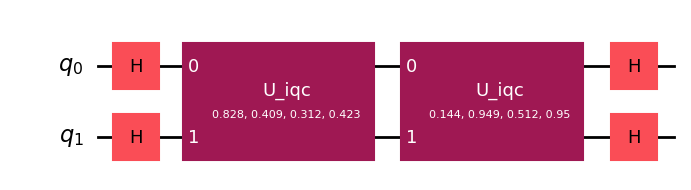

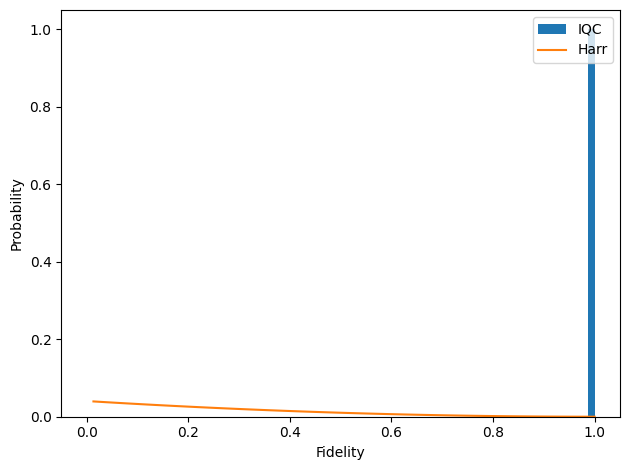

In [5]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]

params=tx+tw
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)

fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    '''
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)'''
    ratio = count.get(string_zero, 0) / n_shots
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [6]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 12.952 nats
S(P || Q): 12.952 nats
KL(P || Q): 12.952 nats


#### Sem objeto _Parameters_

┌───┐┌──────────┐┌──────────┐┌───┐
q_0: ┤ H ├┤0         ├┤0         ├┤ H ├
     ├───┤│  Unitary ││  Unitary │├───┤
q_1: ┤ H ├┤1         ├┤1         ├┤ H ├
     └───┘└──────────┘└──────────┘└───┘

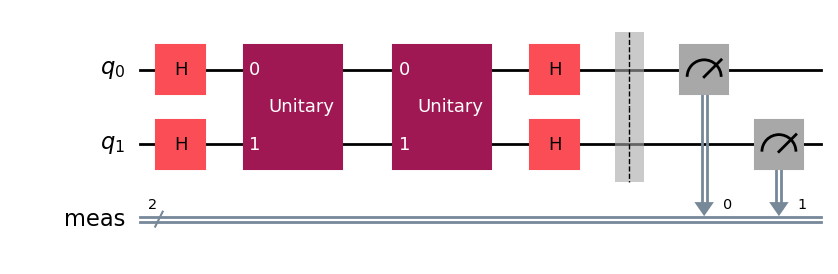

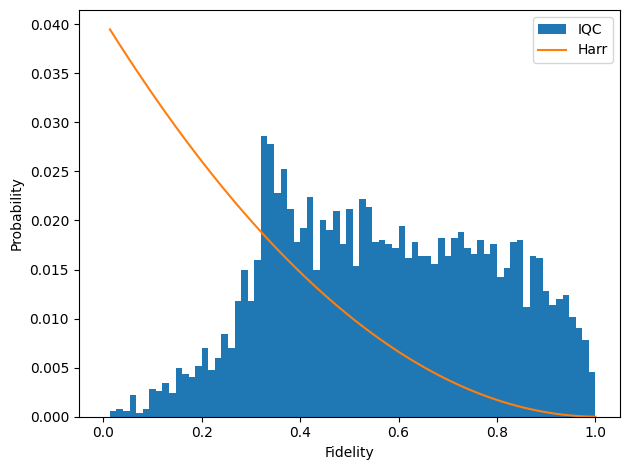

In [11]:
fidelity=[]    
for dd in range(simulation_samples):
    tx = rng.random((2,NF))  # Parâmetros para tx
    tw = rng2.random((2,NF))  # Parâmetros para tw
    #qc,_,_ = circuit_model(data=tx[0],contador=dd,w=tw[0],counter=counter,qubits=qubits,N_qubits=N_qubits,N_features=NF,model=MODEL,folder=folder,N_qubits_tgt=N_qubits_tgt,N_layers=None)
    qc=QuantumCircuit(N_qubits)
    
    U1, X_new1 = get_U(tx[0],tw[0],NF,N_qubits,N_qubits_tgt)
    U2, X_new2 = get_U(tx[1],tw[1],NF,N_qubits,N_qubits_tgt)
    
    qc.h(qubits)
    qc.unitary(U1,qubits)
    qc.unitary(U2,qubits)
    qc.h(qubits)
    if dd==0:
        display(qc.draw())
    
    count=run_qasm_counts_meas_all(qc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)

display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

##### Quantitative Analysis

In [12]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 1.198 nats
S(P || Q): 1.198 nats
KL(P || Q): 1.198 nats


### NF4

In [9]:
MODEL='IQC'
NF=4
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

n_shots=10000
simulation_samples=5000

C:\Users\pichau\AppData\Local\Temp\ipykernel_18924\186343619.py:233: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, cargs in rev_ops:


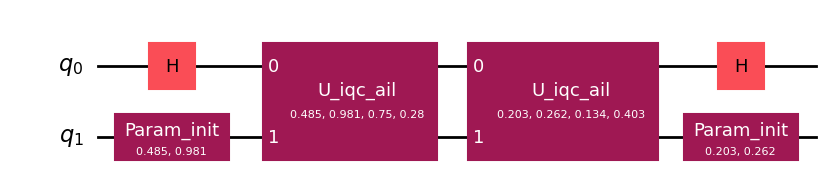

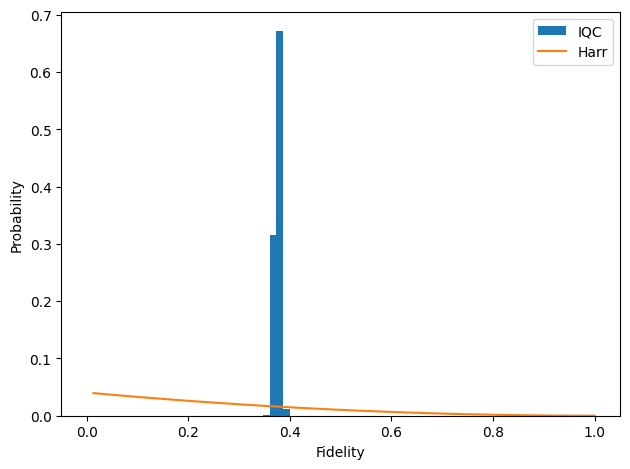

In [10]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]

params=tx+tw
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)

fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [11]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 30.222 nats
S(P || Q): 30.222 nats
KL(P || Q): 30.222 nats


## IQC_AIL

### NF2

In [7]:
MODEL='IQC_AIL'
NF=2
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_zero = '0' * (N_qubits)

n_shots=10000
simulation_samples=5000

#### Sem obj _Parameters_

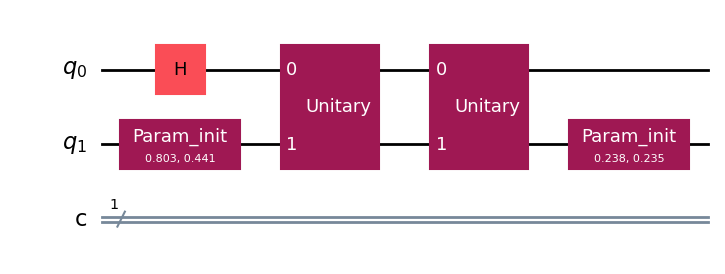

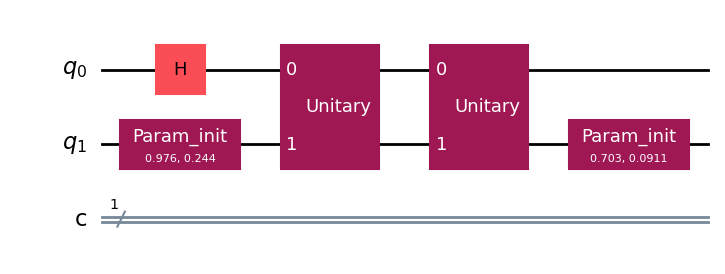

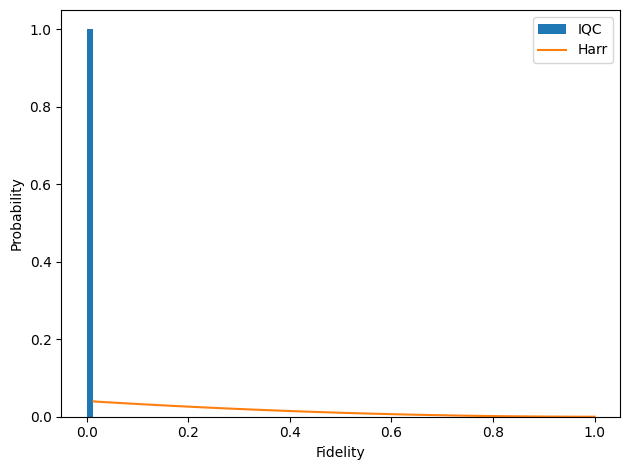

In [ ]:
class ParamInitializeGate(Gate):
    def __init__(self, num_qubits, params, N_features):
        super().__init__("param_init", num_qubits, params)
        self.N_features = N_features
        
    def _define(self):
        q = QuantumRegister(self.num_qubits)
        qc = QuantumCircuit(q)
        
        # Convert parameters to normalized state vector
        params = np.array(self.params, dtype=complex)
        norm = np.linalg.norm(params)
        if norm > 0:
            params = params/norm
            
        qc.initialize(params, q[:])
        self.definition = qc

fidelity=[]    
for dd in range(simulation_samples):
    tx = rng.random((2,NF))  # Parâmetros para tx
    tw = rng2.random((2,NF))  # Parâmetros para tw
    
    qc=QuantumCircuit(N_qubits, N_qubits_tgt)
    
    init_gate1 = ParamInitializeGate(N_qubits-1, tx[0], N_features=NF)
    qc.append(init_gate1, range(1,N_qubits))
    qc.h(0)

    U1, X_new1 = get_U(tx[0],tw[0],NF,N_qubits,N_qubits_tgt,iqcail=True)
    U2, X_new2 = get_U(tx[1],tw[1],NF,N_qubits,N_qubits_tgt, iqcail=True)
    qc.unitary(U1,qubits)
    qc.unitary(U2,qubits)
    init_gate2 = ParamInitializeGate(N_qubits-1, tx[1], N_features=NF)
    qc.append(init_gate2, range(1,N_qubits))
    if dd==0:
        display(qc.draw('mpl'))
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)

    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    '''if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0'''
    ratio = count.get(string_zero, 0) / n_shots
    fidelity.append(ratio)

display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [14]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 3.232 nats
S(P || Q): 3.232 nats
KL(P || Q): 3.232 nats


#### Com obj _Parameters_

C:\Users\pichau\AppData\Local\Temp\ipykernel_18924\186343619.py:233: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, cargs in rev_ops:


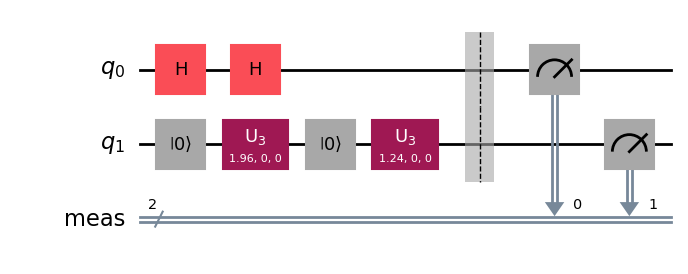

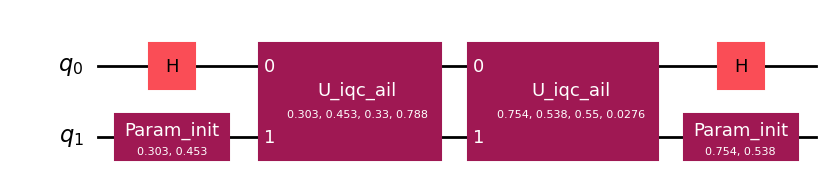

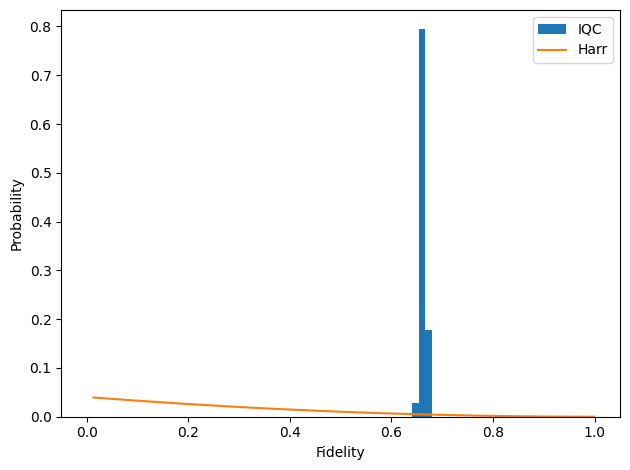

In [ ]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)

fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)

    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    '''if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)'''
    ratio = count.get(string_zero, 0) / n_shots
    fidelity.append(ratio)

display(tqc.draw('mpl'))

display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [9]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 4.797 nats
S(P || Q): 4.797 nats
KL(P || Q): 4.797 nats


### NF4

In [17]:
MODEL='IQC_AIL'
NF=4
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_zero = '0' * (N_qubits)

n_shots=10000
simulation_samples=5000

C:\Users\pichau\AppData\Local\Temp\ipykernel_14884\186343619.py:233: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, cargs in rev_ops:


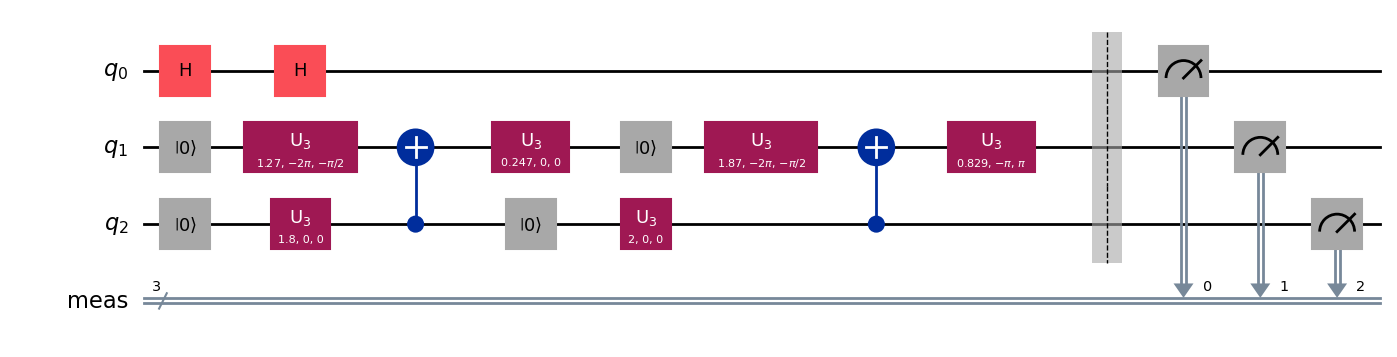

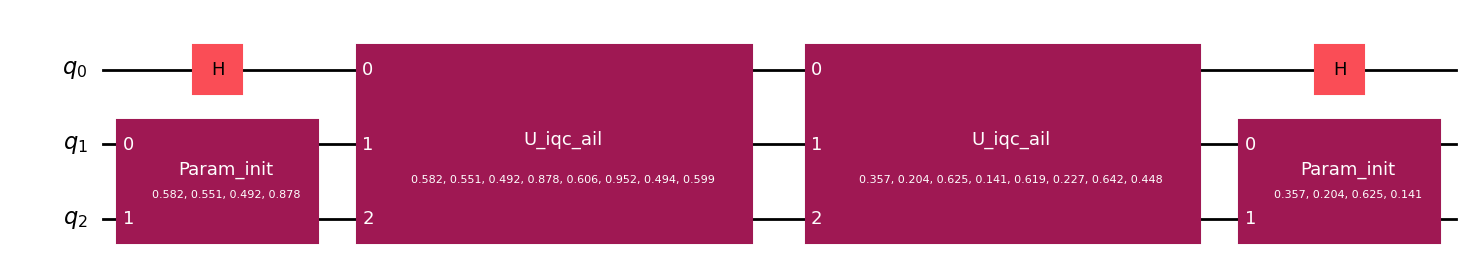

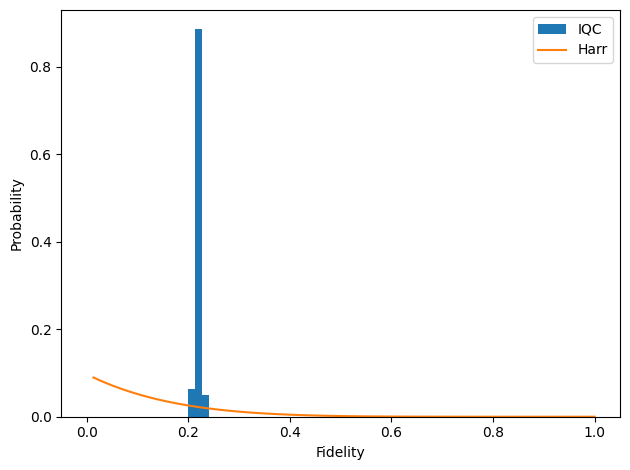

In [ ]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)

fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)

    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    '''if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)'''
    ratio = count.get(string_zero, 0) / n_shots
    fidelity.append(ratio)

display(tqc.draw('mpl'))

display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [19]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 3.426 nats
S(P || Q): 3.426 nats
KL(P || Q): 3.426 nats


## IQCpQ, N_qubits_tgt=2

### NF2

In [20]:
MODEL='IQCpQ'
NF=2
N_qubits_tgt=2
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL+f'_tgt{N_qubits_tgt}'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

n_shots=10000
simulation_samples=5000

#### Com obj _Parameters_

C:\Users\pichau\AppData\Local\Temp\ipykernel_14884\186343619.py:121: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, cargs in rev_ops:


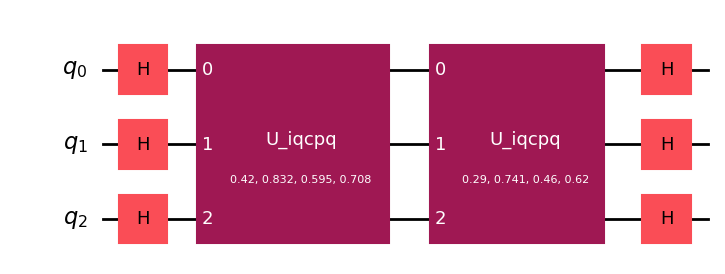

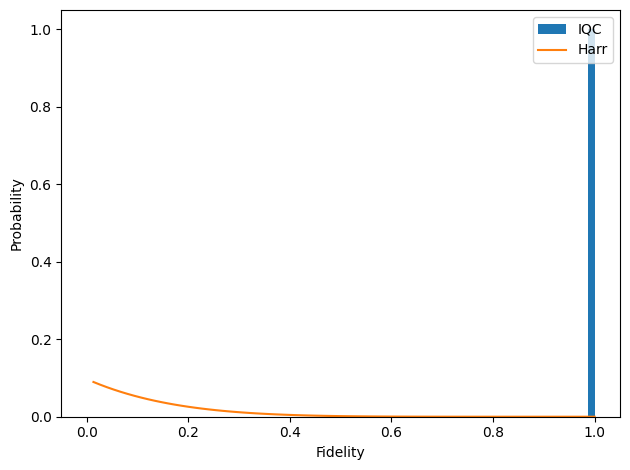

In [ ]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)



fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}_tgt{N_qubits_tgt}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [22]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 30.222 nats
S(P || Q): 30.222 nats
KL(P || Q): 30.222 nats


#### Sem obj _Parameters_

┌───┐┌──────────┐┌──────────┐┌───┐
q_0: ┤ H ├┤0         ├┤0         ├┤ H ├
     ├───┤│          ││          │├───┤
q_1: ┤ H ├┤1 Unitary ├┤1 Unitary ├┤ H ├
     ├───┤│          ││          │├───┤
q_2: ┤ H ├┤2         ├┤2         ├┤ H ├
     └───┘└──────────┘└──────────┘└───┘
c: 2/══════════════════════════════════

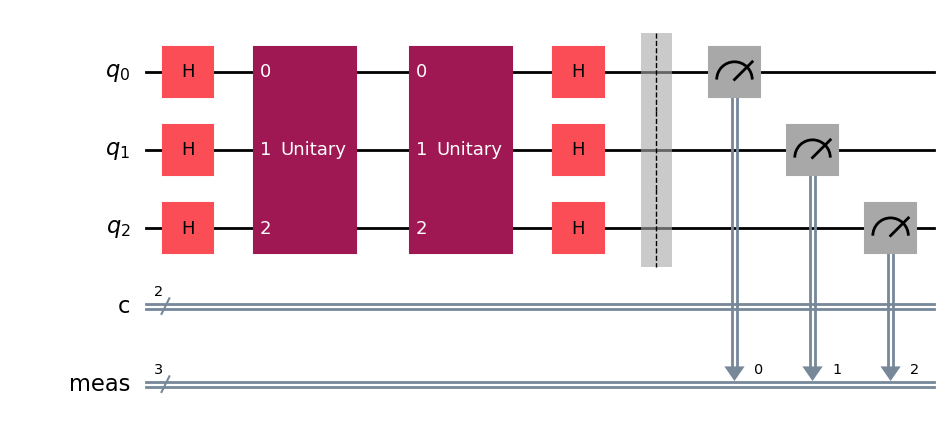

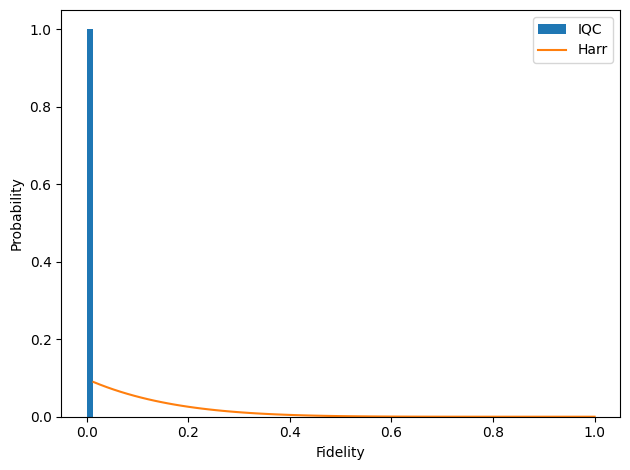

In [ ]:
tx = rng.random((2,NF))  # Parâmetros para tx
tw = rng2.random((2,NF))  # Parâmetros para tw


fidelity=[]    
for dd in range(simulation_samples):
    #qc,_,_ = circuit_model(data=tx[0],contador=dd,w=tw[0],counter=counter,qubits=qubits,N_qubits=N_qubits,N_features=NF,model=MODEL,folder=folder,N_qubits_tgt=N_qubits_tgt,N_layers=None)
    qc=QuantumCircuit(N_qubits, N_qubits_tgt)
    
    U1, X_new1 = get_U(tx[0],tw[0],NF,N_qubits,N_qubits_tgt)
    U2,X_new2 = get_U(tx[1],tw[1],NF,N_qubits,N_qubits_tgt)
    
    qc.h(qubits)
    qc.unitary(U1,qubits)
    qc.unitary(U2,qubits)
    qc.h(qubits)
    if dd==0:
        display(qc.draw())
    
    count=run_qasm_counts_meas_all(qc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [24]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 2.411 nats
S(P || Q): 2.411 nats
KL(P || Q): 2.411 nats


### NF4

In [25]:
MODEL='IQCpQ'
NF=4
N_qubits_tgt=2
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL+f'_tgt{N_qubits_tgt}'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

n_shots=10000
simulation_samples=5000

#### Com obj _Parameters_

C:\Users\pichau\AppData\Local\Temp\ipykernel_14884\186343619.py:121: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, cargs in rev_ops:


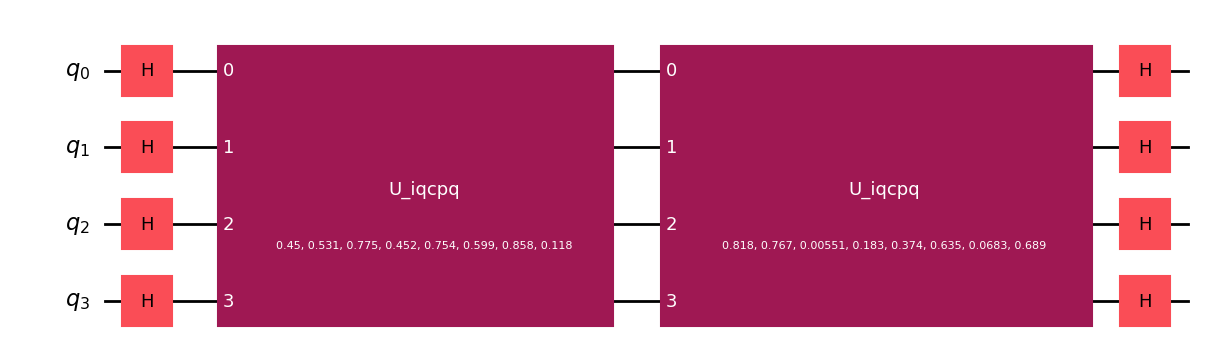

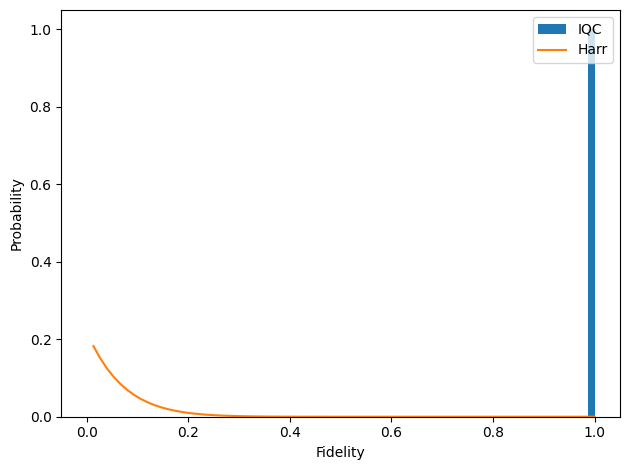

In [ ]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)



fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}_tgt{N_qubits_tgt}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [27]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 64.762 nats
S(P || Q): 64.762 nats
KL(P || Q): 64.762 nats


## IQCpQ, N_qubits_tgt=4

### NF2

In [28]:
MODEL='IQCpQ'
NF=2
N_qubits_tgt=4
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL+f'_tgt{N_qubits_tgt}'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

n_shots=10000
simulation_samples=5000

C:\Users\pichau\AppData\Local\Temp\ipykernel_14884\186343619.py:121: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, cargs in rev_ops:


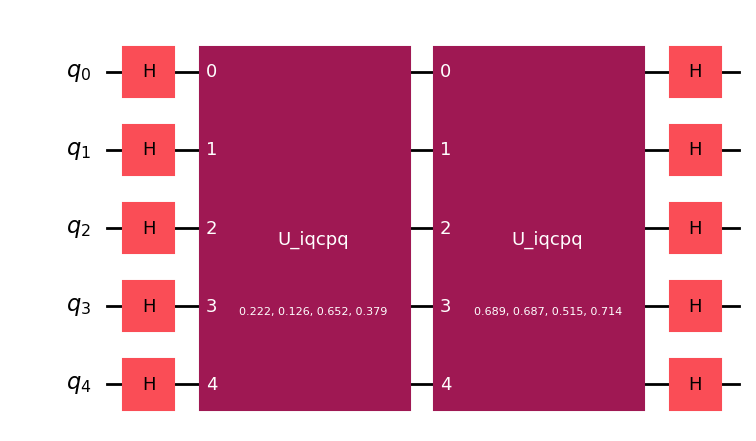

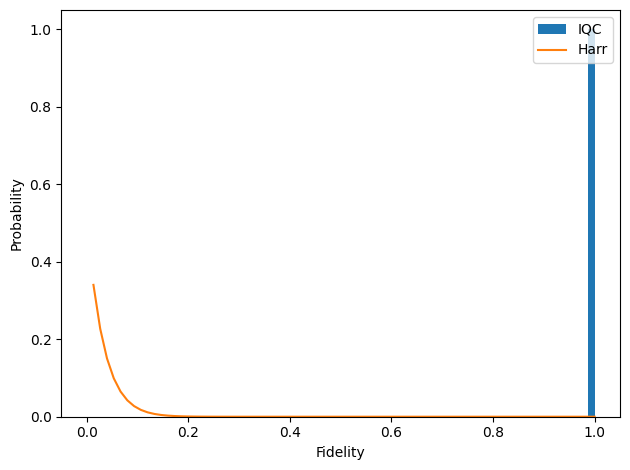

In [ ]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)



fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}_tgt{N_qubits_tgt}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [30]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 133.842 nats
S(P || Q): 133.842 nats
KL(P || Q): 133.842 nats


### NF4

In [31]:
MODEL='IQCpQ'
NF=4
N_qubits_tgt=4
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt) #Nqubits do circuito
string_zero='0'*N_qubits #Fazendo a String de controle para calcularmos a fidelidade do circuito
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL+f'_tgt{N_qubits_tgt}'
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)

qasm_simulator = Aer.get_backend("qasm_simulator")

n_shots=10000
simulation_samples=5000

C:\Users\pichau\AppData\Local\Temp\ipykernel_14884\186343619.py:121: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, cargs in rev_ops:


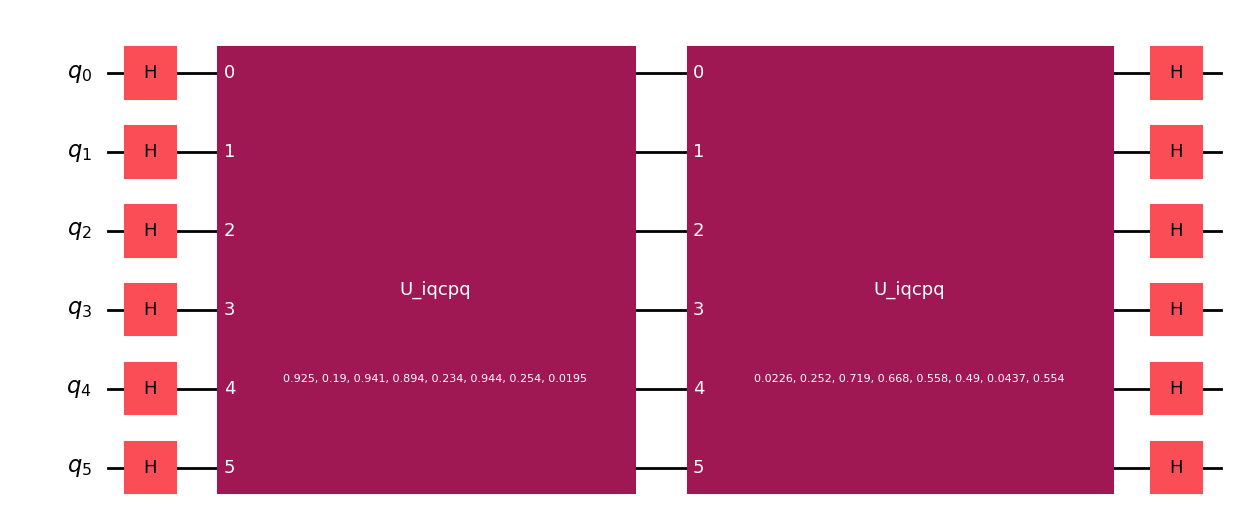

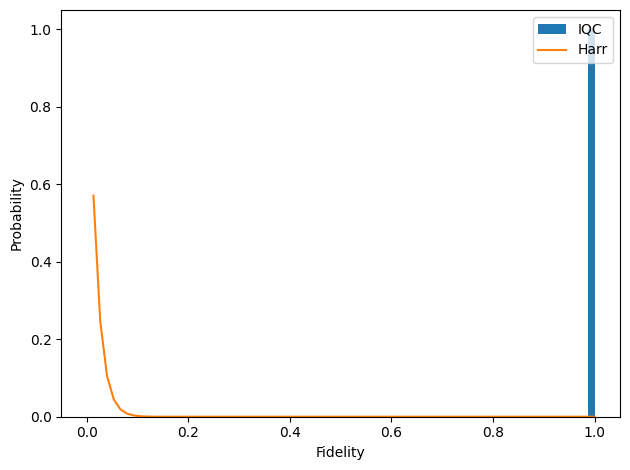

In [ ]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)



fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}_tgt{N_qubits_tgt}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [33]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 272.002 nats
S(P || Q): 272.002 nats
KL(P || Q): 272.002 nats


## IQCNDsE

### NF2

In [34]:
MODEL='IQCNDsE'
NF=2
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_zero = '0' * (N_qubits)

n_shots=10000
simulation_samples=5000

#### Com obj _Parameters_

C:\Users\pichau\AppData\Local\Temp\ipykernel_14884\186343619.py:121: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, cargs in rev_ops:


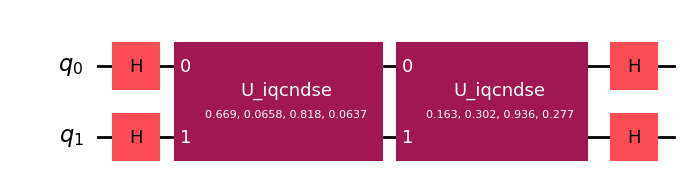

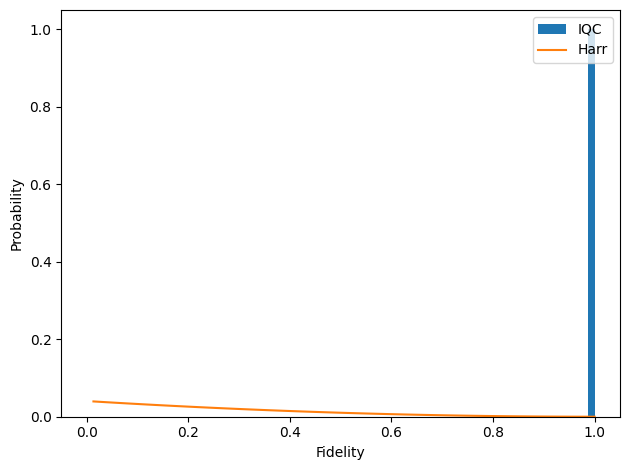

In [ ]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)


aa={}
fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    aa=param_binding
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [36]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 12.952 nats
S(P || Q): 12.952 nats
KL(P || Q): 12.952 nats


### NF4

In [37]:
MODEL='IQCNDsE'
NF=4
N_qubits_tgt=1
N_qubits=math.ceil(np.log2(NF)+N_qubits_tgt)
counter=0
qubits=[i for i in range(N_qubits)]

P_harr_hist, bins_x, bins_list=bins(N_qubits=N_qubits)

folder=f'NF{NF}_'+MODEL
# Check if the diretory does exists and create it, if it doesn't
if not os.path.exists(folder):
    os.makedirs(folder)
qasm_simulator = Aer.get_backend("qasm_simulator")

string_zero = '0' * (N_qubits)

n_shots=10000
simulation_samples=5000

C:\Users\pichau\AppData\Local\Temp\ipykernel_14884\186343619.py:121: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, cargs in rev_ops:


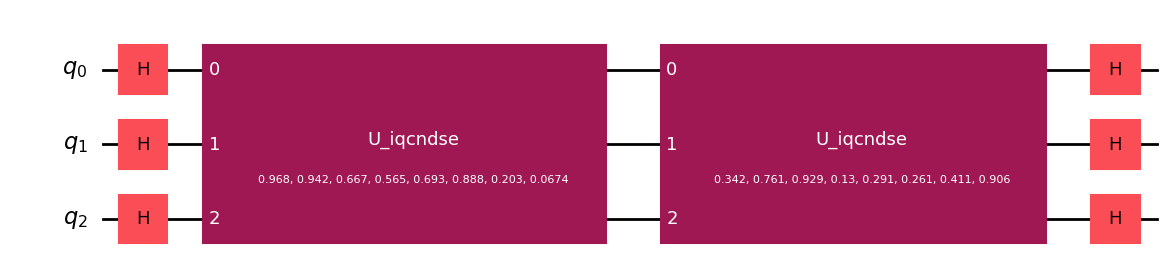

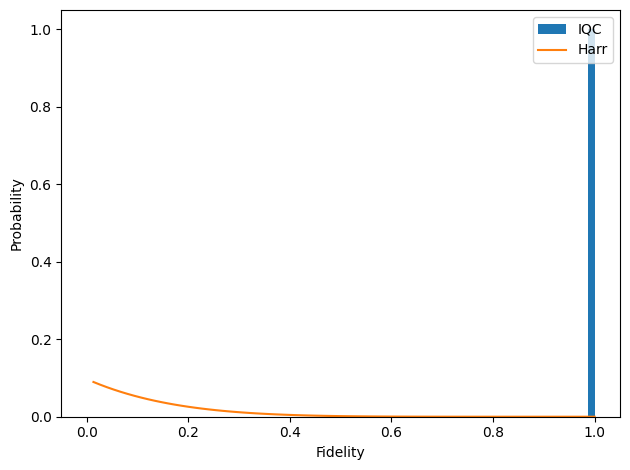

In [ ]:
tx = [Parameter(f'x{i}') for i in range(NF)]
tw = [Parameter(f'pw{i}') for i in range(NF)]
params=tx+tw
#kl_pq = get_KL_divergence(circuitm(model='IQC',N_features=NF,N_qubits=N_qubits,N_qubits_tgt=N_qubits_tgt,params=params), n_shots=10000,nparams=5000, backend=qasm_simulator, reuse_circuit_measures=True)
qc=circuitm(MODEL,NF,N_qubits,N_qubits_tgt,params=params)


aa={}
fidelity=[]    
for _ in range(simulation_samples):
    param_binding = {p : rng.random() for p in qc.parameters}
    qc.assign_parameters(param_binding, inplace=True)
    aa=param_binding
    
    tqc=transpile(qc, optimization_level=0, basis_gates=['u3', 'x', 'h', 'z', 'cx'], seed_transpiler=1)
    
    count=run_qasm_counts_meas_all(tqc, n_shots)
    
    
    
    if string_zero in count and '1' in count:
        ratio=count[string_zero]/n_shots
    elif string_zero in count and '1' not in count:
        ratio=count[string_zero]/n_shots
    else:
        ratio=0
    fidelity.append(ratio)
    
display(qc.draw('mpl', filename=folder+f'/mpl_meas_tgt_U_NF{NF}_{MODEL}.svg'))

weights = np.ones_like(fidelity)/float(len(fidelity))
plt.hist(fidelity, bins=bins_list, weights=weights, range=[0, 1], label='IQC')
plt.plot(bins_x, P_harr_hist, label='Harr')
plt.legend(loc='upper right')
plt.ylabel('Probability')
plt.xlabel('Fidelity')
plt.show()

In [39]:
# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = rel_entr(P_I_hist, P_harr_hist)
print('rel_entry(P || Q): %.3f nats' % sum(kl_pq))

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = entropy(P_I_hist, P_harr_hist)
print('S(P || Q): %.3f nats' % kl_pq)

# example of calculating the kl divergence (relative entropy) with scipy
P_I_hist=np.histogram(fidelity, bins=bins_list, weights=weights, range=[0, 1])[0]
kl_pq = kl_div(P_I_hist, P_harr_hist)
print('KL(P || Q): %.3f nats' %sum(kl_pq))

rel_entry(P || Q): 30.222 nats
S(P || Q): 30.222 nats
KL(P || Q): 30.222 nats
